In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter
from config import config

from scipy.stats import chi2_contingency

plt.style.use('fivethirtyeight')

# Анализ данных (EDA)

Анализ проводится на выборке Train/CV. Holdout остаётся нетронутым и используется только для финальной оценки моделей.

In [3]:
from src.data import load_data, split_train_holdout

TARGET = 'SalePrice'
ID_COLUMN = 'Id'

train_df, test_df = load_data(config)
train_cv_df, holdout_df = split_train_holdout(train_df, config)

# Для EDA используем только Train/CV, чтобы не анализировать holdout.
eda_df = train_cv_df.copy()

print('Полный train:', train_df.shape)
print('Train/CV для EDA:', eda_df.shape)
print('Нетронутый holdout:', holdout_df.shape)
print('Kaggle test:', test_df.shape)

with pd.option_context('display.max_columns', None):
    display(eda_df.head(10).style.hide(axis='index'))

Полный train: (1460, 81)
Train/CV для EDA: (1168, 81)
Нетронутый holdout: (292, 81)
Kaggle test: (1459, 80)


Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
727,20,RL,nan,21695,Pave,nan,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,1Story,6,9,1988,2007,Hip,CompShg,Wd Sdng,Plywood,BrkFace,260.000000,Gd,Gd,CBlock,Gd,TA,No,GLQ,808,Unf,0,72,880,GasA,Ex,Y,SBrkr,1680,0,0,1680,1,0,2,0,3,1,Gd,5,Typ,1,Gd,Attchd,1988.000000,Fin,2,540,TA,TA,Y,292,44,0,182,0,0,nan,nan,nan,0,12,2009,WD,Normal,222000
241,20,FV,75.000000,9000,Pave,nan,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2008,2008,Gable,CompShg,VinylSd,VinylSd,Stone,36.000000,Gd,TA,PConc,Gd,TA,Av,GLQ,1078,Unf,0,488,1566,GasA,Ex,Y,SBrkr,1566,0,0,1566,1,0,2,0,3,1,Gd,7,Typ,0,nan,Attchd,2008.000000,RFn,2,750,TA,TA,Y,144,168,0,0,0,0,nan,nan,nan,0,4,2010,WD,Normal,262500
95,60,RL,69.000000,9337,Pave,nan,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,6,5,1997,1997,Gable,CompShg,VinylSd,VinylSd,None,0.000000,TA,Gd,PConc,Gd,TA,No,GLQ,648,Unf,0,176,824,GasA,Ex,Y,SBrkr,905,881,0,1786,1,0,2,1,3,1,Gd,7,Typ,0,nan,Attchd,1997.000000,RFn,2,684,TA,TA,Y,0,162,0,0,0,0,nan,nan,nan,0,5,2007,WD,Normal,204750
1408,20,RL,nan,8780,Pave,nan,IR1,Lvl,AllPub,Corner,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,5,1985,1985,Gable,CompShg,HdBoard,Plywood,None,0.000000,TA,TA,CBlock,TA,TA,No,ALQ,625,Unf,0,208,833,GasA,Ex,Y,SBrkr,833,0,0,833,1,0,1,0,3,1,TA,5,Typ,0,nan,nan,nan,nan,0,0,nan,nan,Y,0,0,0,0,0,0,nan,MnPrv,nan,0,3,2009,WD,Normal,112000
1417,190,RM,60.000000,11340,Pave,nan,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,2fmCon,2Story,4,6,1885,1950,Gable,CompShg,VinylSd,AsbShng,None,0.000000,TA,TA,PConc,TA,TA,No,Unf,0,Unf,0,777,777,GasA,Gd,Y,SBrkr,1246,1044,0,2290,0,0,2,0,4,2,TA,11,Typ,0,nan,Detchd,1971.000000,Unf,2,560,TA,TA,N,0,0,114,0,0,0,nan,nan,nan,0,4,2010,WD,Normal,122500
636,190,RH,60.000000,10896,Pave,Pave,Reg,Bnk,AllPub,Inside,Gtl,SWISU,Feedr,Norm,2fmCon,2.5Fin,6,7,1914,1995,Hip,CompShg,VinylSd,VinylSd,None,0.000000,Fa,TA,CBlock,TA,Fa,No,LwQ,256,Unf,0,1184,1440,GasA,Ex,Y,FuseA,1440,1440,515,3395,0,0,2,0,8,2,Fa,14,Typ,0,nan,nan,nan,nan,0,0,nan,nan,N,0,110,0,0,0,0,nan,nan,nan,0,3,2007,WD,Abnorml,200000
1283,20,RL,61.000000,8800,Pave,nan,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,1Story,5,7,1977,2008,Gable,CompShg,HdBoard,HdBoard,None,0.000000,TA,TA,CBlock,Gd,TA,Mn,LwQ,532,Rec,144,364,1040,GasA,TA,Y,SBrkr,1040,0,0,1040,0,0,2,0,3,1,Gd,5,Typ,0,nan,Detchd,1977.000000,Unf,2,484,TA,TA,Y,0,0,0,0,288,0,nan,nan,nan,0,9,2009,WD,Normal,150500
1219,50,RM,52.000000,6240,Pave,nan,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,Norm,1Fam,1.5Fin,4,5,1947,1950,Gable,CompShg,AsbShng,AsbShng,None,0.000000,TA,TA,Slab,nan,nan,nan,nan,0,nan,0,0,0,GasA,Gd,N,SBrkr,672,240,0,912,0,0,1,0,2,1,TA,3,Typ,0,nan,nan,nan,nan,0,0,nan,nan,N,0,0,0,0,0,0,nan,nan,nan,0,7,2006,WD,Normal,80500
914,90,RH,82.000000,6270,Pave,nan,Reg,HLS,AllPub,Inside,Gtl,Crawfor,Norm,Norm,Duplex,2Story,5,6,1949,1950,Gable,CompShg,MetalSd,MetalSd,None,0.000000,TA,TA,CBlock,TA,TA,No,BLQ,284,Unf,0,717,1001,GasA,TA,N,FuseA,1001,1001,0,2002,0,0,2,0,4,2,TA,8,Typ,0,nan,2Types,1949.000000,Unf,3,871,TA,TA,Y,0,0,0,0,0,0,nan,nan,nan,0,8,2007,WD,Normal,145000
644,60,RL,80.000000,10793,Pave,nan,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,RRAn,Norm,1Fam,2Story,5,5,1969,1969,Mansard,CompShg,W

## 1. Общая информация о данных

Проверим размер выборки, количество числовых и категориальных features, типы данных и наличие пропусков.

In [4]:
features_df = eda_df.drop(columns=[TARGET, ID_COLUMN])

numerical_columns = features_df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = features_df.select_dtypes(exclude=np.number).columns.tolist()

print('Количество samples:', len(eda_df))
print('Количество features:', features_df.shape[1])
print('Числовые features:', len(numerical_columns))
print('Категориальные features:', len(categorical_columns))
print('Объём памяти:', f'{eda_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

eda_df.info(memory_usage='deep')

Количество samples: 1168
Количество features: 79
Числовые features: 35
Категориальные features: 44
Объём памяти: 2.82 MB
<class 'pandas.DataFrame'>
Index: 1168 entries, 726 to 1241
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   object 
 2   MSZoning       1168 non-null   str    
 3   LotFrontage    955 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   str    
 6   Alley          68 non-null     str    
 7   LotShape       1168 non-null   str    
 8   LandContour    1168 non-null   str    
 9   Utilities      1168 non-null   str    
 10  LotConfig      1168 non-null   str    
 11  LandSlope      1168 non-null   str    
 12  Neighborhood   1168 non-null   str    
 13  Condition1     1168 non-null   str    
 14  Condition2     1168 non-null   str    
 15  BldgType       1168 non-null   st

### Вывод

Выборка содержит 1168 samples и 79 features: 35 numerical и 44 categorical. Типы данных определены корректно, однако в ряде features есть пропуски, их количество и смысл рассмотрим отдельно.

MSSubClass был изменен вручную при создании датасета. Например, исходные 20, 30, 60, 120 являются кодами типов жилья и были отнесены к категориальным features.

## 2. Дубликаты

Проверим полные дубликаты, а также совпадения без `Id` и `SalePrice`. Удалять найденные строки будем только после анализа.

In [5]:
# Полные строки, включая Id и SalePrice
duplicates_with_id = eda_df.duplicated().sum()

# Одинаковые объекты с одинаковой ценой, но потенциально разными Id
duplicates_without_id = eda_df.drop(columns=ID_COLUMN).duplicated().sum()

# Одинаковые характеристики объектов без учёта Id и SalePrice
duplicates_by_features = features_df.duplicated().sum()

print('Полные дубликаты:', duplicates_with_id)
print('Дубликаты без Id:', duplicates_without_id)
print('Дубликаты только по features:', duplicates_by_features)

Полные дубликаты: 0
Дубликаты без Id: 0
Дубликаты только по features: 0


### Вывод

Дубликаты не обнаружены ни при сравнении полных строк, ни после исключения `Id`, ни при сравнении только признаков объекта. Удаление строк не требуется.

## 3. Уникальные значения

Проверим количество уникальных значений и найдём features, в которых одно значение занимает почти всю выборку. Такие features могут содержать мало полезной информации, однако их редкие значения иногда описывают важные особенности домов.

In [6]:
NEAR_CONSTANT_THRESHOLD = 95

feature_summary = pd.DataFrame({
    'unique_values': features_df.nunique(dropna=False),
    'most_frequent': features_df.apply(lambda column: column.value_counts(dropna=False).index[0]),
    'dominant_share': features_df.apply(lambda column: column.value_counts(dropna=False, normalize=True).iloc[0] * 100),
})

feature_summary.index.name = 'feature'
feature_summary = feature_summary.sort_values('dominant_share', ascending=False)

constant_features = feature_summary.query('unique_values == 1')
near_constant_features = feature_summary.query('unique_values > 1 and dominant_share >= @NEAR_CONSTANT_THRESHOLD')

print('Constant features:', len(constant_features))
print('Near-constant features:', len(near_constant_features))

display(near_constant_features.round(3))

Constant features: 0
Near-constant features: 12


,unique_values,most_frequent,dominant_share
feature,,,
Utilities,2,AllPub,99.914
Street,2,Pave,99.658
PoolArea,7,0,99.486
PoolQC,4,NaN,99.486
Condition2,8,Norm,98.887
3SsnPorch,18,0,98.202
RoofMatl,8,CompShg,98.116
LowQualFinSF,20,0,98.116
Heating,6,GasA,98.031


### Вывод

Constant features не обнаружены. Найдено 12 near-constant features, в которых одно значение занимает не менее 95% наблюдений.

Низкая вариативность ещё не означает бесполезность: редкие значения некоторых признаков описывают реальные особенности домов, например наличие бассейна или нестандартного отопления.

## 4. Пропущенные значения

Рассмотрим количество и долю `NaN` в каждом feature. В House Prices пропуск не всегда означает потерянное значение: иногда он обозначает отсутствие объекта, например бассейна, гаража или камина.

In [7]:
missing_summary = pd.DataFrame({
    'missing_count': features_df.isna().sum(),
    'missing_share': features_df.isna().mean() * 100,
    'dtype': features_df.dtypes.astype(str),
})

missing_summary = missing_summary.query('missing_count > 0').sort_values('missing_share', ascending=False)
missing_summary.index.name = 'feature'

print('Features с пропусками:', len(missing_summary))
print('Всего пропущенных значений:', missing_summary['missing_count'].sum())

display(missing_summary.round(3))

Features с пропусками: 19
Всего пропущенных значений: 5534


,missing_count,missing_share,dtype
feature,,,
PoolQC,1162,99.486,str
MiscFeature,1127,96.490,str
Alley,1100,94.178,str
Fence,951,81.421,str
FireplaceQu,527,45.120,str
LotFrontage,213,18.236,float64
GarageCond,60,5.137,str
GarageType,60,5.137,str
GarageYrBlt,60,5.137,float64


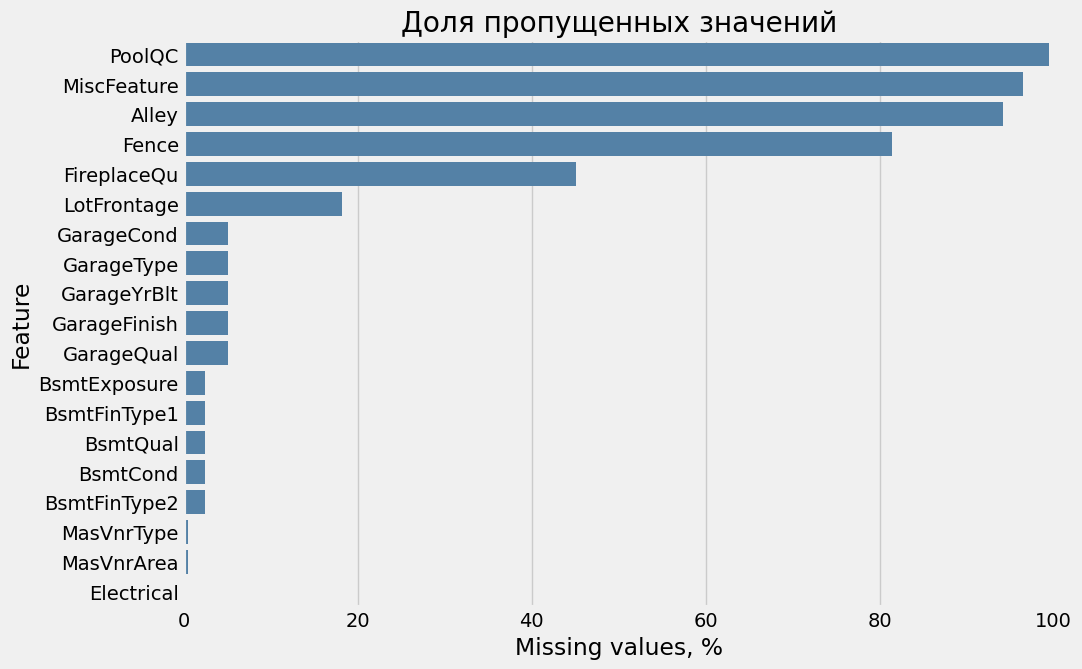

In [8]:
plt.figure(figsize=(10, 7))

sns.barplot(data=missing_summary.reset_index(), x='missing_share', y='feature', color='steelblue')
plt.title('Доля пропущенных значений')
plt.xlabel('Missing values, %')
plt.ylabel('Feature')
plt.xlim(0, 100)

plt.show()

In [9]:
basement_columns = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'TotalBsmtSF']

# Ищем пропуск BsmtExposure у дома, в котором подвал действительно существует
basement_missing = eda_df.loc[
    eda_df['BsmtExposure'].isna() & eda_df['TotalBsmtSF'].gt(0),
    [ID_COLUMN] + basement_columns,
]

display(basement_missing.style.hide(axis='index'))

Id,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,TotalBsmtSF
949,Gd,TA,nan,Unf,Unf,936


In [10]:
display(eda_df['MasVnrType'].value_counts(dropna=False))

# Проверяем строки с неизвестным типом или площадью облицовки
masonry_missing = eda_df.loc[
    eda_df['MasVnrType'].isna() | eda_df['MasVnrArea'].isna(),
    [ID_COLUMN, 'MasVnrType', 'MasVnrArea'],
]

display(masonry_missing.style.hide(axis='index'))

MasVnrType
None       685
BrkFace    362
Stone      101
BrkCmn      14
NaN          6
Name: count, dtype: int64

Id,MasVnrType,MasVnrArea
235,nan,nan
530,nan,nan
1279,nan,nan
651,nan,nan
937,nan,nan
978,nan,nan


### Вывод

Большинство пропусков являются structural missing и обозначают отсутствие бассейна, гаража, подвала, камина или другого объекта. Настоящие неизвестные значения встречаются преимущественно в `LotFrontage`, `MasVnrType`, `MasVnrArea`, `Electrical` и отдельных строках basement features. Поэтому features с высокой долей `NaN` не удаляем, а способы заполнения разделим по смыслу пропуска.### Интерпретация пропусков

Пропуски разделяются на две группы:

- **structural missing** — значение отсутствует вместе с самим объектом;
- **настоящий пропуск** — объект или характеристика существуют, но значение неизвестно.

`LotFrontage` — длина границы участка вдоль улицы. `NaN` не означает отсутствие выхода к улице, поэтому считаем его настоящим пропуском.

Пропуски в garage features, включая `GarageYrBlt`, преимущественно означают отсутствие гаража. Аналогично пропуски в `PoolQC`, `FireplaceQu`, `Alley`, `Fence` и большинстве basement features описывают отсутствие соответствующего объекта.

`Electrical` считаем настоящим пропуском: отсутствие электричества не предусмотрено описанием признака.

Для `MasVnrType` отсутствие облицовки уже обозначается категорией `None`, а для `MasVnrArea` — значением `0`. Поэтому оставшиеся `NaN` считаем настоящими пропусками.

| Тип пропуска          | Features                                                                          | Обработка                                                      |
| --------------------- | --------------------------------------------------------------------------------- | -------------------------------------------------------------- |
| Отсутствует объект    | `PoolQC`, `Alley`, `Fence`, `FireplaceQu`, garage и большинство basement features | Отдельная категория `NoPool`, `NoGarage`, `NoBasement` и т. п. |
| Неизвестное число     | `LotFrontage`, `MasVnrArea`                                                       | Imputation, возможно missing indicator                         |
| Неизвестная категория | `MasVnrType`, `Electrical`, единичный `BsmtExposure`                              | `Unknown` или наиболее частое значение                         |


### Настоящие и структурные пропуски

Отделим настоящие неизвестные значения от structural missing. Для этого используем связанные числовые features и описание датасета.

In [11]:
true_missing_mask = features_df.isna().copy()

no_pool = features_df['PoolArea'].eq(0)
no_fireplace = features_df['Fireplaces'].eq(0)
no_garage = features_df['GarageCars'].eq(0) & features_df['GarageArea'].eq(0)
no_basement = features_df['TotalBsmtSF'].eq(0)

structural_missing_rules = {
    'PoolQC': no_pool,
    'MiscFeature': features_df['MiscFeature'].isna(),
    'Alley': features_df['Alley'].isna(),
    'Fence': features_df['Fence'].isna(),
    'FireplaceQu': no_fireplace,
    'GarageType': no_garage,
    'GarageYrBlt': no_garage,
    'GarageFinish': no_garage,
    'GarageQual': no_garage,
    'GarageCond': no_garage,
    'BsmtQual': no_basement,
    'BsmtCond': no_basement,
    'BsmtExposure': no_basement,
    'BsmtFinType1': no_basement,
    'BsmtFinType2': no_basement,
}

# Исключаем structural missing из маски настоящих пропусков
for column, structural_mask in structural_missing_rules.items():
    true_missing_mask.loc[structural_mask, column] = False

In [12]:
true_missing_summary = pd.DataFrame({
    'missing_count': true_missing_mask.sum(),
    'missing_share': true_missing_mask.mean() * 100,
})

true_missing_summary = true_missing_summary.query('missing_count > 0').sort_values('missing_share', ascending=False)
true_missing_summary.index.name = 'feature'

print('Настоящих пропусков:', true_missing_summary['missing_count'].sum())
display(true_missing_summary.round(3))

Настоящих пропусков: 227


,missing_count,missing_share
feature,,
LotFrontage,213,18.236
MasVnrType,6,0.514
MasVnrArea,6,0.514
BsmtExposure,1,0.086
Electrical,1,0.086


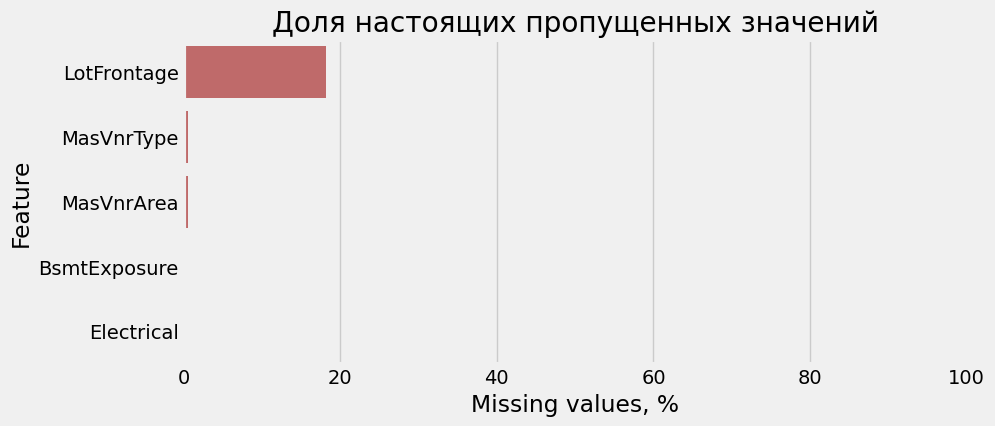

In [13]:
plt.figure(figsize=(9, 4))

sns.barplot(data=true_missing_summary.reset_index(), x='missing_share', y='feature', color='indianred')
plt.title('Доля настоящих пропущенных значений')
plt.xlabel('Missing values, %')
plt.ylabel('Feature')
plt.xlim(0, 100)

plt.show()

### Вывод

Из 5534 исходных `NaN` только 227 считаем настоящими пропусками. Большая часть остальных значений является structural missing и сообщает об отсутствии бассейна, гаража, подвала, камина или другого объекта.

Из 227 настоящих пропусков 213 относятся к `LotFrontage`. Кроме них обнаружены 6 пропусков в `MasVnrType`, 6 в `MasVnrArea` и по одному в `BsmtExposure` и `Electrical`.

Удалять features с высокой исходной долей `NaN` нельзя: во многих случаях сам факт отсутствия объекта содержит полезную информацию. Правила заполнения реализуем внутри preprocessing pipeline, чтобы imputation обучался отдельно на каждом CV fold.

## 5. Анализ target

Исследуем распределение `SalePrice` и проверим, как логарифмическое преобразование влияет на его асимметрию. Это особенно важно для Linear Regression и соответствует основной метрике.

In [14]:
target = eda_df[TARGET]
target_log = np.log(target)

assert target.gt(0).all()

print(target.describe().round(2))
print(f'\nSkewness SalePrice: {target.skew():.3f}')
print(f'Skewness log(SalePrice): {target_log.skew():.3f}')

count      1168.00
mean     182584.47
std       79728.58
min       34900.00
25%      131475.00
50%      164945.00
75%      215400.00
max      755000.00
Name: SalePrice, dtype: float64

Skewness SalePrice: 1.928
Skewness log(SalePrice): 0.122


In [15]:
price_formatter = FuncFormatter(lambda value, position: f'${value / 1000:,.0f}k')
log_price_formatter = FuncFormatter(lambda value, position: f'${np.exp(value) / 1000:,.0f}k')

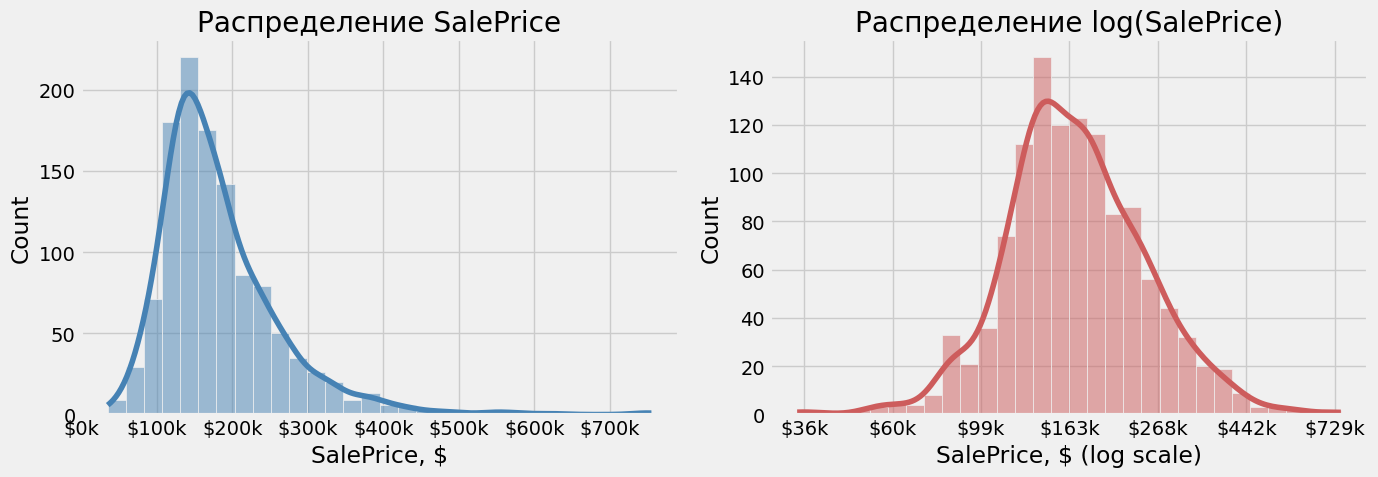

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(target, bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение SalePrice')
axes[0].set_xlabel('SalePrice, $')
axes[0].xaxis.set_major_formatter(price_formatter)

sns.histplot(target_log, bins=30, kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Распределение log(SalePrice)')
axes[1].set_xlabel('SalePrice, $ (log scale)')
axes[1].xaxis.set_major_formatter(log_price_formatter)

plt.tight_layout()
plt.show()

### Вывод

Исходный `SalePrice` сильно скошен вправо: skewness равен 1.928. После логарифмирования skewness снижается до 0.122, а распределение становится значительно более симметричным.

Поэтому в качестве target будем использовать `log(SalePrice)`. Окончательно пользу преобразования оценим по результатам CV.

### Потенциальные выбросы по IQR

`IQR = Q3 − Q1` описывает разброс центральных 50% наблюдений. Значения ниже `Q1 − 1.5 × IQR` и выше `Q3 + 1.5 × IQR` считаются потенциальными выбросами.

Коэффициент `1.5` — общепринятое эвристическое правило, а не строгий критерий удаления. Поэтому найденные наблюдения сначала исследуем отдельно.

In [17]:
def calculate_iqr_summary(values):
    '''Calculate IQR boundaries and count potential outliers.'''

    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = (values.lt(lower_bound) | values.gt(upper_bound)).sum()

    return pd.Series({
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'potential_outliers': outlier_count,
    })


outlier_summary = pd.DataFrame({
    'SalePrice': calculate_iqr_summary(target),
    'log(SalePrice)': calculate_iqr_summary(target_log),
}).T

display(outlier_summary.round(3))

,q1,q3,iqr,lower_bound,upper_bound,potential_outliers
SalePrice,131475.000,215400.00,83925.000,5587.500,341287.500,49.0
log(SalePrice),11.787,12.28,0.494,11.046,13.021,25.0


In [18]:
log_lower_bound = outlier_summary.loc['log(SalePrice)', 'lower_bound']
log_upper_bound = outlier_summary.loc['log(SalePrice)', 'upper_bound']

log_lower_price = np.exp(log_lower_bound)
log_upper_price = np.exp(log_upper_bound)

print(f'Нижняя граница log-target в долларах: ${log_lower_price:,.2f}')
print(f'Верхняя граница log-target в долларах: ${log_upper_price:,.2f}')

Нижняя граница log-target в долларах: $62,696.05
Верхняя граница log-target в долларах: $451,697.94


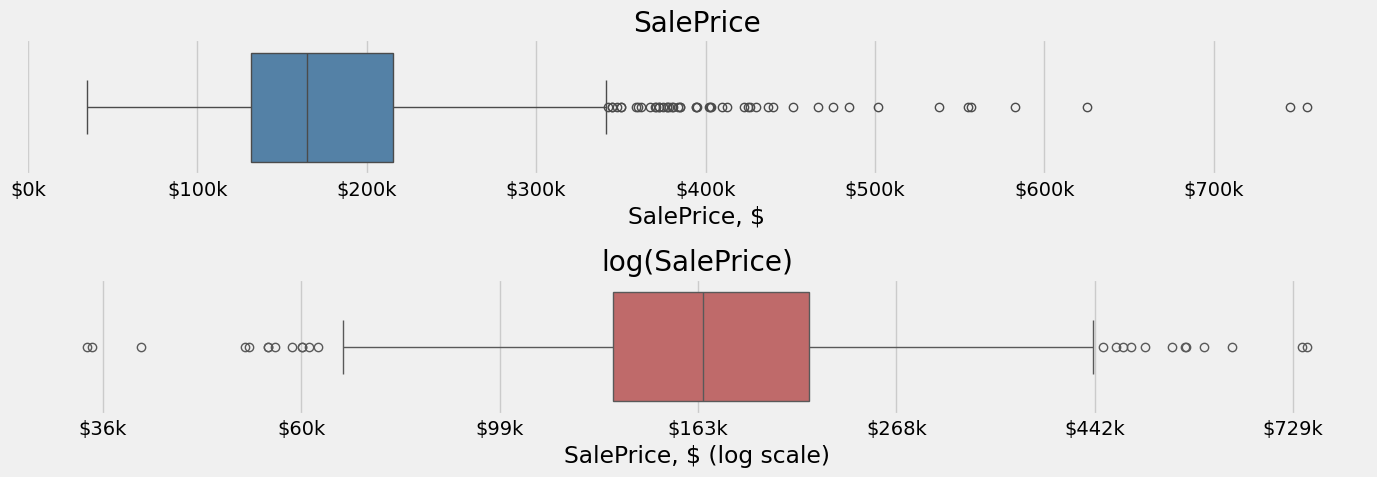

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

sns.boxplot(x=target, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice')
axes[0].set_xlabel('SalePrice, $')
axes[0].xaxis.set_major_formatter(price_formatter)

sns.boxplot(x=target_log, ax=axes[1], color='indianred')
axes[1].set_title('log(SalePrice)')
axes[1].set_xlabel('SalePrice, $ (log scale)')
axes[1].xaxis.set_major_formatter(log_price_formatter)

plt.tight_layout()
plt.show()

In [20]:
lower_outlier_mask = target_log.lt(log_lower_bound)
upper_outlier_mask = target_log.gt(log_upper_bound)
log_outlier_mask = lower_outlier_mask | upper_outlier_mask

print('Нижние потенциальные выбросы:', lower_outlier_mask.sum())
print('Верхние потенциальные выбросы:', upper_outlier_mask.sum())
print('Всего:', log_outlier_mask.sum())

Нижние потенциальные выбросы: 13
Верхние потенциальные выбросы: 12
Всего: 25


### Вывод

По правилу `1.5 × IQR` исходный `SalePrice` содержит 49 потенциальных выбросов выше `$341,287`. После логарифмирования остаётся 25 наблюдений за границами, соответствующими ценам ниже `$62,696` и выше `$451,698`. Эти дома являются редкими, но пока не считаются ошибочными и не удаляются.

In [21]:
outlier_columns = [
    ID_COLUMN, TARGET, 'SaleType', 'SaleCondition', 'Neighborhood', 'OverallQual',
    'GrLivArea', 'LotArea', 'TotalBsmtSF', 'YearBuilt', 'YrSold',
]

outliers = eda_df.loc[log_outlier_mask, outlier_columns].sort_values(TARGET)
display(outliers.style.hide(axis='index').format({TARGET: '${:,.0f}'}))

Id,SalePrice,SaleType,SaleCondition,Neighborhood,OverallQual,GrLivArea,LotArea,TotalBsmtSF,YearBuilt,YrSold
496,"$34,900",WD,Abnorml,IDOTRR,4,720,7879,720,1920,2009
917,"$35,311",WD,Abnorml,IDOTRR,2,480,9000,480,1949,2006
31,"$40,000",WD,Normal,IDOTRR,4,1317,8500,649,1920,2008
711,"$52,000",WD,Normal,BrkSide,3,729,4130,270,1935,2008
1338,"$52,500",WD,Normal,OldTown,4,693,4118,693,1941,2006
706,"$55,000",WD,Normal,IDOTRR,4,1092,5600,0,1930,2010
1326,"$55,000",WD,Normal,IDOTRR,4,796,3636,796,1922,2008
813,"$55,993",WD,Alloca,IDOTRR,5,1044,8712,540,1952,2010
1381,"$58,500",WD,Normal,Edwards,3,864,8212,864,1914,2010
1101,"$60,000",WD,Normal,SWISU,2,438,8400,290,1920,2009


In [22]:
display(pd.crosstab(eda_df['SaleType'], eda_df['SaleCondition'], margins=True))

SaleCondition,Abnorml,AdjLand,Alloca,Family,Normal,Partial,All
SaleType,,,,,,,
COD,17,0,0,0,15,0,32
CWD,1,0,0,1,2,0,4
Con,0,0,0,0,1,0,1
ConLD,2,0,0,0,3,0,5
ConLI,1,0,0,0,3,0,4
ConLw,0,0,0,0,4,0,4
New,0,0,0,0,0,97,97
Oth,1,0,0,0,0,0,1
WD,51,4,9,19,936,1,1020


In [23]:
sale_summary = (
    eda_df.groupby(['SaleType', 'SaleCondition'], observed=True)
    .agg(samples=(TARGET, 'size'), median_price=(TARGET, 'median'), mean_price=(TARGET, 'mean'))
    .sort_values('median_price')
)

display(sale_summary.style.format({'median_price': '${:,.0f}', 'mean_price': '${:,.0f}'}))

,,samples,median_price,mean_price
SaleType,SaleCondition,,,
ConLD,Abnorml,2,"$82,450","$82,450"
WD,AdjLand,4,"$104,000","$104,125"
ConLI,Normal,3,"$115,000","$225,650"
WD,Partial,1,"$115,000","$115,000"
ConLI,Abnorml,1,"$125,000","$125,000"
COD,Normal,15,"$126,500","$143,743"
CWD,Family,1,"$136,000","$136,000"
WD,Abnorml,51,"$140,000","$159,946"
COD,Abnorml,17,"$140,000","$141,371"


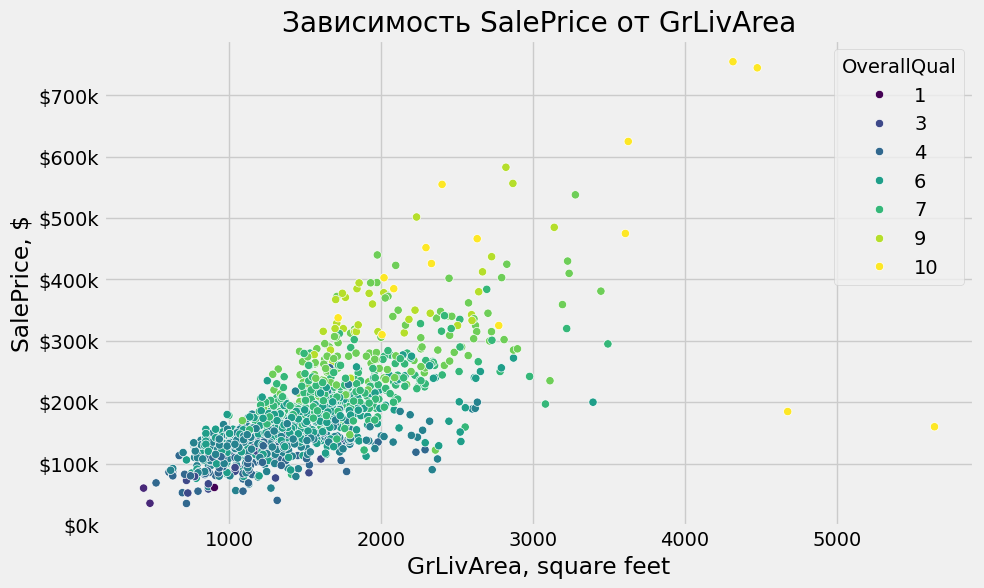

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=eda_df, x='GrLivArea', y=TARGET, hue='OverallQual', palette='viridis')
plt.title('Зависимость SalePrice от GrLivArea')
plt.xlabel('GrLivArea, square feet')
plt.ylabel('SalePrice, $')
plt.gca().yaxis.set_major_formatter(price_formatter)

plt.show()

In [47]:
large_houses = (
    eda_df.loc[eda_df['GrLivArea'].gt(4000), outlier_columns]
    .assign(price_per_sqft=lambda df: df[TARGET] / df['GrLivArea'])
    .sort_values('GrLivArea', ascending=False)
)

display(large_houses.style.hide(axis='index').format({TARGET: '${:,.0f}', 'price_per_sqft': '${:,.2f}'}))

Id,SalePrice,SaleType,SaleCondition,Neighborhood,OverallQual,GrLivArea,LotArea,TotalBsmtSF,YearBuilt,YrSold,price_per_sqft
1299,"$160,000",New,Partial,Edwards,10,5642,63887,6110,2008,2008,$28.36
524,"$184,750",New,Partial,Edwards,10,4676,40094,3138,2007,2007,$39.51
1183,"$745,000",WD,Abnorml,NoRidge,10,4476,15623,2396,1996,2007,$166.44
692,"$755,000",WD,Normal,NoRidge,10,4316,21535,2444,1994,2007,$174.93


In [26]:
# Очень большая жилая площадь при неожиданно низкой цене
candidate_outlier_mask = eda_df['GrLivArea'].gt(4000) & eda_df[TARGET].lt(300000)
candidate_outlier_ids = eda_df.loc[candidate_outlier_mask, ID_COLUMN].tolist()

print('Кандидаты на исключение:', candidate_outlier_ids)

Кандидаты на исключение: [524, 1299]


### Вывод

Крайние значения `SalePrice` в основном объясняются площадью, качеством, возрастом и расположением домов. Необычный тип или условие сделки объясняет только часть низких и высоких цен.

На графике `SalePrice — GrLivArea` выделяются два особенно крупных дома с неожиданно низкой ценой — `Id 524` и `Id 1299`. Такие наблюдения могут непропорционально сильно влиять на Linear Regression.

Пока их не удаляем. Позднее проведём отдельный эксперимент и сравним CV на всех данных и без этих двух наблюдений.

## 6. Корреляция numerical features с target

Рассчитаем Pearson correlation между numerical features и `log(SalePrice)`. Она показывает направление и силу линейной связи, но не учитывает нелинейные зависимости и categorical features.

In [28]:
correlation_df = features_df[numerical_columns].copy()
correlation_df['log_SalePrice'] = target_log

# Сортируем features по абсолютной силе связи с target
target_correlations = correlation_df.corr()['log_SalePrice'].drop('log_SalePrice')
target_correlations = target_correlations.sort_values(key=abs, ascending=False)

display(target_correlations.to_frame('correlation').round(3))

,correlation
feature,
OverallQual,0.810
GrLivArea,0.705
GarageCars,0.695
GarageArea,0.669
FullBath,0.612
TotalBsmtSF,0.597
1stFlrSF,0.588
YearBuilt,0.581
YearRemodAdd,0.553


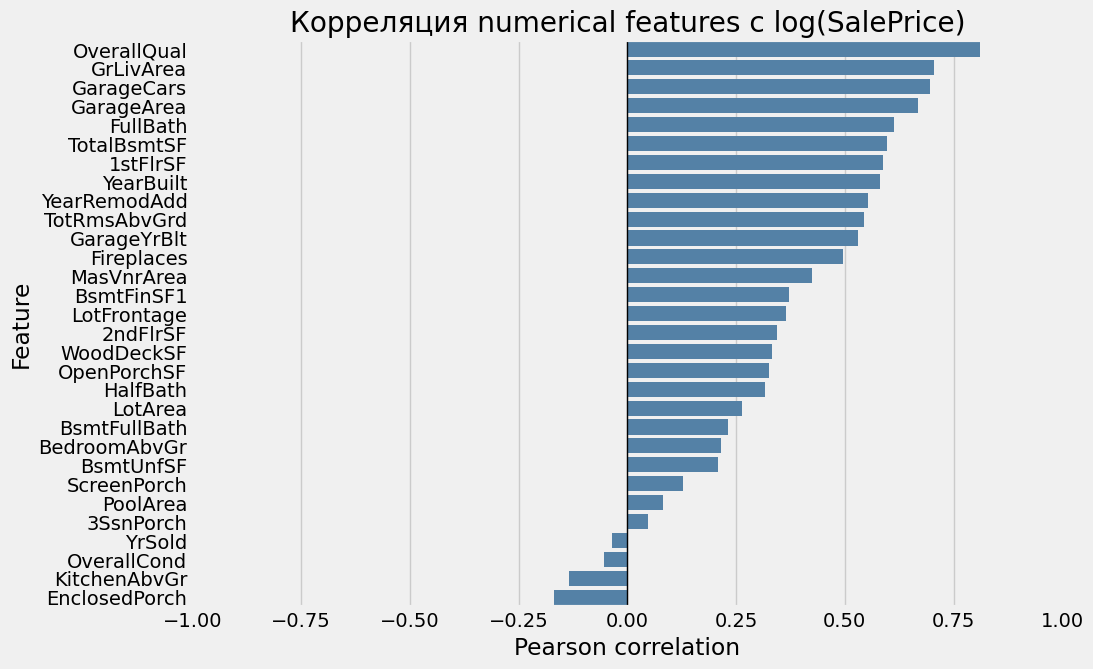

In [29]:
top_correlations = target_correlations.head(30).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_correlations.values, y=top_correlations.index, color='steelblue')

plt.axvline(0, color='black', linewidth=1)
plt.title('Корреляция numerical features с log(SalePrice)')
plt.xlabel('Pearson correlation')
plt.ylabel('Feature')
plt.xlim(-1, 1)
plt.show()

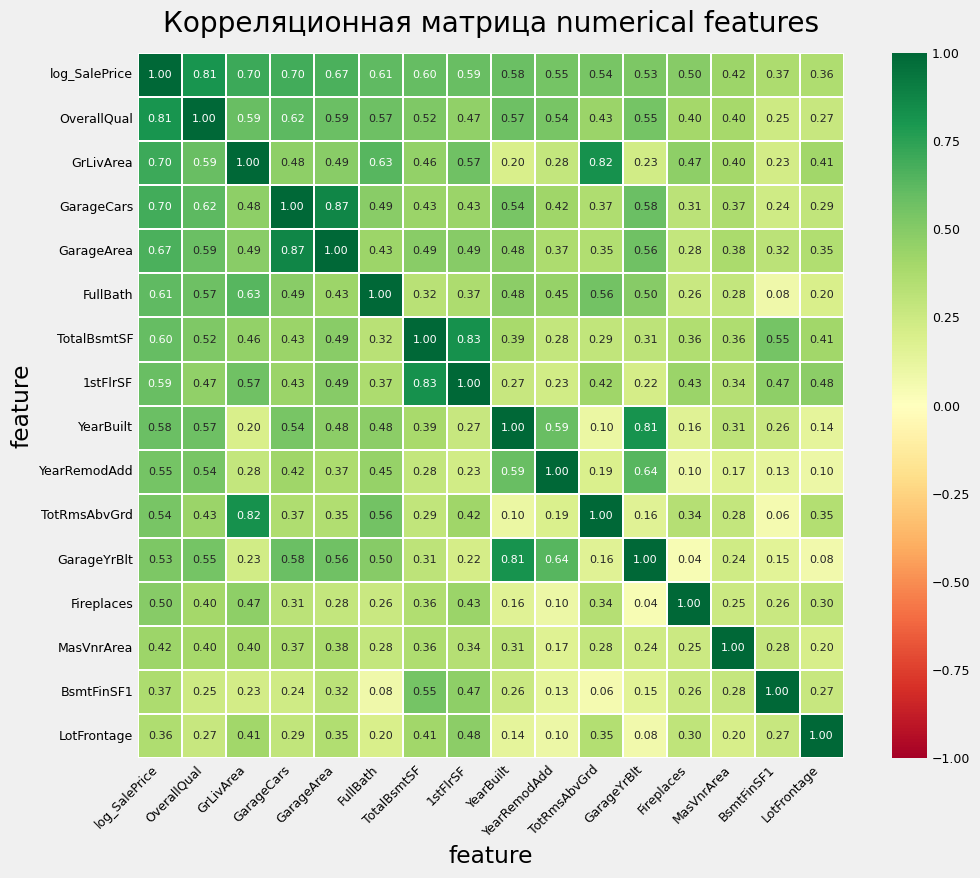

In [30]:
heatmap_features = target_correlations.head(15).index.tolist()
heatmap_columns = ['log_SalePrice'] + heatmap_features

corr_matrix = correlation_df[heatmap_columns].corr()

plt.figure(figsize=(11, 9))

ax = sns.heatmap(corr_matrix, annot=True, fmt='.2f', vmin=-1, vmax=1, center=0, cmap='RdYlGn', linewidths=0.2, annot_kws={'size': 8}, square=True,)

plt.title('Корреляционная матрица numerical features', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

### Вывод

Корреляционный анализ показывает, что цена дома связана с несколькими группами характеристик: качеством, площадью, возрастом, гаражом и дополнительными удобствами.

Наиболее сильную линейную связь с `log(SalePrice)` имеют:

- `OverallQual` — 0.81;
- `GrLivArea` — 0.70;
- `GarageCars` — 0.70;
- `GarageArea` — 0.67;
- `FullBath` — 0.61;
- `TotalBsmtSF` — 0.60.

Таким образом, цена связана не только с размером дома, но и с общим качеством материалов и отделки, вместимостью гаража, площадью подвала и количеством полноценных ванных комнат.

Numerical features образуют несколько взаимосвязанных групп:

- размер дома: `GrLivArea`, `TotRmsAbvGrd`, `FullBath`, `1stFlrSF`;
- гараж: `GarageCars`, `GarageArea`, `GarageYrBlt`;
- возраст: `YearBuilt`, `YearRemodAdd`, `GarageYrBlt`;
- площадь основания дома: `TotalBsmtSF`, `1stFlrSF`;
- общий класс объекта: `OverallQual`, площадь, возраст и характеристики гаража.

Наиболее сильные связи между самими features:

- `GarageCars` и `GarageArea` — 0.87;
- `TotalBsmtSF` и `1stFlrSF` — 0.83;
- `GrLivArea` и `TotRmsAbvGrd` — 0.82;
- `YearBuilt` и `GarageYrBlt` — 0.81.

Эти зависимости имеют содержательное объяснение: вместительный гараж обычно имеет большую площадь, количество комнат увеличивается вместе с жилой площадью, площадь подвала связана с footprint первого этажа, а гараж часто строится одновременно с домом.

`OverallQual` связан с площадью, количеством ванных комнат, характеристиками гаража и годом постройки. При этом его корреляция с target выше, чем с каждым из этих features по отдельности. Следовательно, он содержит дополнительную информацию об общем качестве объекта.

`BedroomAbvGr` связан с ценой заметно слабее, чем `GrLivArea`: количество спален не заменяет информацию об общей жилой площади. Корреляция `LotArea` составляет только 0.26, поскольку влияние площади участка зависит также от района, формы, рельефа и расположения.

`KitchenAbvGr` и `EnclosedPorch` имеют слабую отрицательную связь с ценой. Несколько кухонь выше уровня земли могут встречаться в duplex или переоборудованных домах, а закрытые веранды — в более старых объектах.

`MoSold` и `YrSold` почти не имеют линейной связи с target. Это не исключает сезонности или различий между отдельными годами. Аналогично, слабая корреляция `PoolArea`, `3SsnPorch`, `MiscVal` и других редких features не доказывает их бесполезность: Pearson correlation плохо отражает эффект признаков, в которых большинство значений равно нулю.

Признаков очевидного data leakage не обнаружено: наиболее сильные связи имеют содержательное объяснение и относятся к характеристикам, известным до продажи дома.

#### Использование результатов для Linear Regression

Первый linear baseline построим на всех features с `log(SalePrice)` в качестве target. Затем сравним Linear Regression с Ridge, Lasso и ElasticNet.

Удалять features по одному не будем. По результатам EDA сформируем несколько групп кандидатов:

- редкие и near-constant features;
- features со слабой связью с target;
- сильно коррелирующие features;
- потенциально избыточные исходные features после Feature Engineering.

Каждую группу будем исключать отдельным экспериментом и оценивать изменение `RMSE(log)` на одинаковых CV folds. Связанные features пока сохраняем, а основным linear baseline планируем использовать Ridge.

Дополнительно планируем:

- проверить `log1p` для скошенных numerical features;
- создать `TotalSF`, `TotalBathrooms`, `HouseAge` и `RemodAge`;
- проверить indicators `HasPool`, `HasFireplace`, `HasGarage` и `HasBasement`;
- отдельно сравнить CV с домами `Id 524`, `Id 1299` и без них.

## 7. Связь categorical features с target

Pearson correlation нельзя напрямую применять к nominal categorical features. Вместо произвольного присвоения категориям чисел рассчитаем `eta squared` - долю вариативности `log(SalePrice)`, которая связана с различиями между категориями.

In [31]:
def calculate_eta_squared(categories, values):
    '''Calculate the strength of association between categories and a numerical target.'''

    data = pd.DataFrame({'category': categories.astype('object').fillna('Missing'), 'target': values})

    overall_mean = data['target'].mean()
    group_stats = data.groupby('category')['target'].agg(['count', 'mean'])

    between_group_variance = (group_stats['count'] * (group_stats['mean'] - overall_mean) ** 2).sum()

    total_variance = ((data['target'] - overall_mean) ** 2).sum()

    return between_group_variance / total_variance

In [32]:
categorical_effects = pd.DataFrame({
    'eta_squared': {
        column: calculate_eta_squared(features_df[column], target_log)
        for column in categorical_columns
    },
    'unique_values': features_df[categorical_columns].nunique(dropna=False),
})

categorical_effects = categorical_effects.sort_values('eta_squared', ascending=False)

display(categorical_effects.head(44).round(3)) # There are 44 categorical features

,eta_squared,unique_values
Neighborhood,0.571,25
BsmtQual,0.444,5
KitchenQual,0.441,4
ExterQual,0.433,4
GarageFinish,0.370,4
MSSubClass,0.334,15
GarageType,0.329,7
FireplaceQu,0.312,6
Foundation,0.285,6
HeatingQC,0.231,5


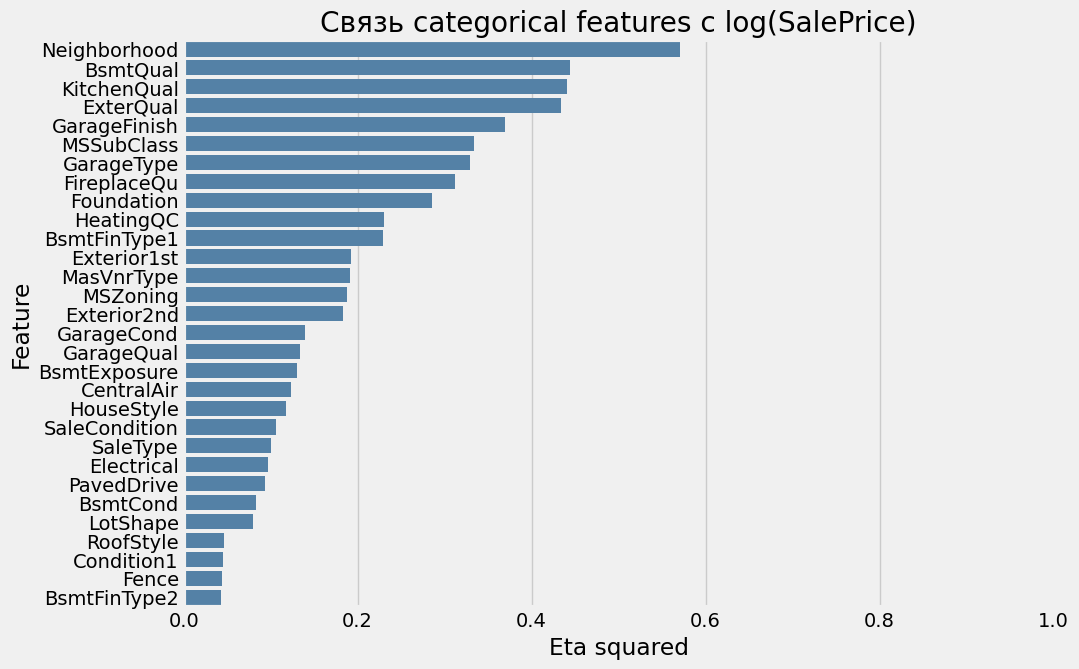

In [33]:
top_categorical_effects = categorical_effects.head(30).sort_values('eta_squared', ascending=False)

plt.figure(figsize=(10, 7))

sns.barplot(x=top_categorical_effects['eta_squared'], y=top_categorical_effects.index, color='steelblue',)

plt.title('Связь categorical features с log(SalePrice)')
plt.xlabel('Eta squared')
plt.ylabel('Feature')
plt.xlim(0, 1)
plt.show()

Функция Cramér’s V

In [34]:
def calculate_cramers_v(first_feature, second_feature):
    '''Calculate bias-corrected Cramér's V between two categorical features.'''

    contingency_table = pd.crosstab(first_feature, second_feature)
    chi_squared = chi2_contingency(contingency_table, correction=False)[0]

    samples = contingency_table.to_numpy().sum()
    rows, columns = contingency_table.shape

    if samples <= 1 or rows <= 1 or columns <= 1:
        return 0.0

    phi_squared = chi_squared / samples
    phi_squared_corrected = max(0, phi_squared - ((columns - 1) * (rows - 1)) / (samples - 1),)

    rows_corrected = rows - ((rows - 1) ** 2) / (samples - 1)
    columns_corrected = columns - ((columns - 1) ** 2) / (samples - 1)
    denominator = min(rows_corrected - 1, columns_corrected - 1)

    if denominator <= 0:
        return 0.0

    return np.sqrt(phi_squared_corrected / denominator)

In [35]:
categorical_data = features_df[categorical_columns].astype('string').fillna('Missing')
cramers_matrix = pd.DataFrame(np.eye(len(categorical_columns)), index=categorical_columns, columns=categorical_columns)

# Рассчитываем Cramér’s V для каждой уникальной пары features
for first_index, first_feature in enumerate(categorical_columns):
    for second_feature in categorical_columns[first_index + 1:]:
        association = calculate_cramers_v(categorical_data[first_feature], categorical_data[second_feature])

        cramers_matrix.loc[first_feature, second_feature] = association
        cramers_matrix.loc[second_feature, first_feature] = association

In [36]:
# Берём только уникальные пары из верхнего треугольника матрицы
upper_triangle_mask = np.triu(np.ones(cramers_matrix.shape, dtype=bool), k=1)

cramers_pairs = (
    cramers_matrix.where(upper_triangle_mask).stack().sort_values(ascending=False)
    .rename('cramers_v').rename_axis(['feature_1', 'feature_2']).reset_index()
)

display(cramers_pairs.head(20).style.hide(axis='index').format({'cramers_v': '{:.3f}'}))

feature_1,feature_2,cramers_v
MSSubClass,BldgType,0.896
MSSubClass,HouseStyle,0.841
Exterior1st,Exterior2nd,0.759
GarageType,GarageFinish,0.692
GarageQual,GarageCond,0.684
MSZoning,Neighborhood,0.648
GarageFinish,GarageQual,0.589
GarageFinish,GarageCond,0.584
BsmtQual,BsmtFinType1,0.578
PoolQC,MiscFeature,0.575


In [37]:
# Отбираем 15 categorical features с наиболее сильной связью с target
eta_squared_scores = pd.Series({
    column: calculate_eta_squared(features_df[column], target_log)
    for column in categorical_columns
}).sort_values(ascending=False)

top_categorical_features = eta_squared_scores.head(15).index.tolist()
top_cramers_matrix = cramers_matrix.loc[top_categorical_features, top_categorical_features]

# Скрываем повторяющиеся значения над главной диагональю
heatmap_mask = np.triu(np.ones(top_cramers_matrix.shape, dtype=bool), k=1)

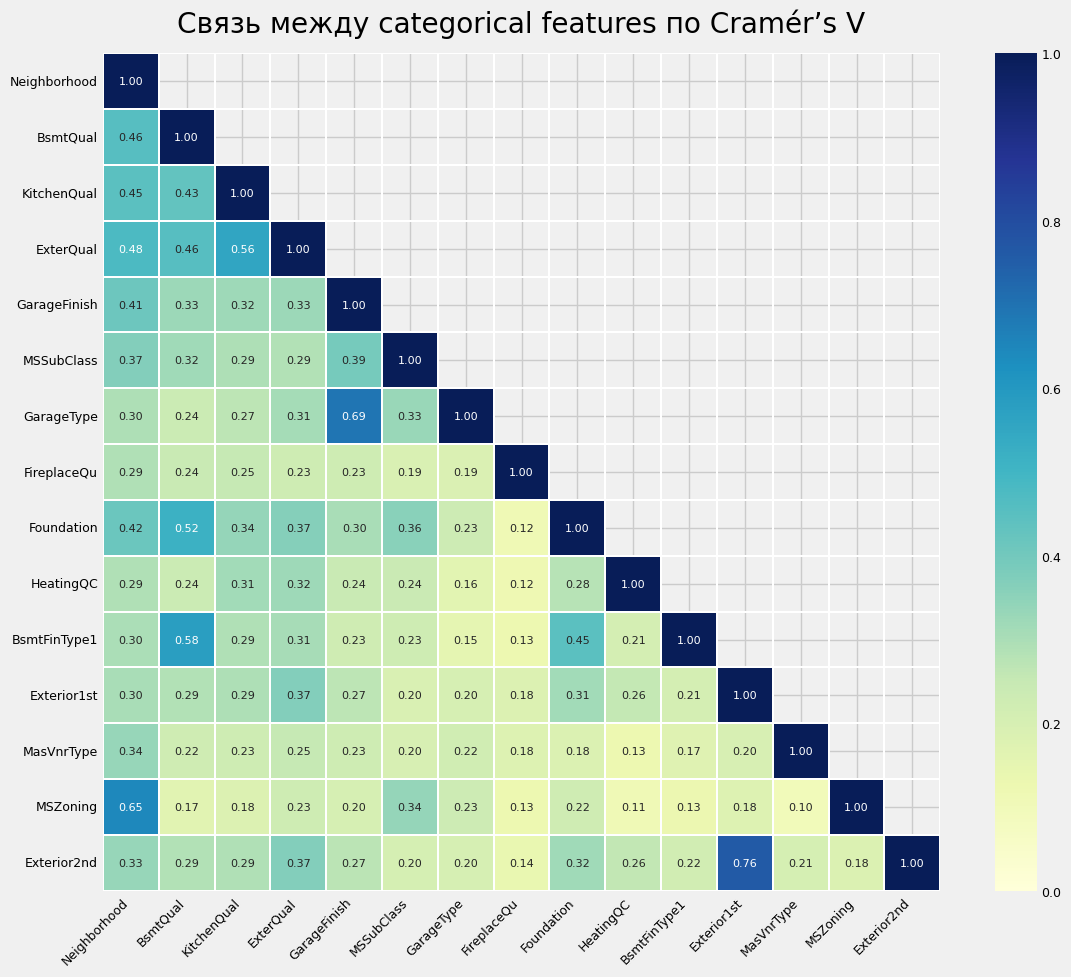

In [38]:
plt.figure(figsize=(12, 10))

ax = sns.heatmap(top_cramers_matrix, mask=heatmap_mask, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='YlGnBu', linewidths=0.2, annot_kws={'size': 8}, square=True,)

plt.title('Связь между categorical features по Cramér’s V', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

### Вывод

Анализ `eta squared` подтвердил, что расположение дома и качество отдельных объектов существенно связаны с `log(SalePrice)`. Наибольшую связь показывает `Neighborhood`, далее следуют качество подвала, кухни, внешней отделки и характеристики гаража.

Большинство редких и near-constant features имеют слабую связь с target. Однако редкость сама по себе не доказывает бесполезность. Например, `FireplaceQu` имеет `eta_squared = 0.312`: его `NaN` обозначают отсутствие камина, поэтому feature одновременно содержит информацию о наличии камина и его качестве.

Матрица Cramér’s V дополнила анализ и выявила группы связанных categorical features:

- `MSSubClass`, `BldgType`, `HouseStyle`;
- `Exterior1st`, `Exterior2nd`;
- `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`;
- `Neighborhood`, `MSZoning`;
- группа basement features.

Некоторые связи отражают возможное дублирование информации, а другие - логическое устройство дома или общие structural missing.

Первый linear baseline обучим на всех features. В качестве кандидатов на последующие CV-эксперименты рассмотрим:

- `BldgType` и `HouseStyle` при сохранении `MSSubClass`;
- `Exterior2nd` при сохранении `Exterior1st`;
- `GarageQual` и `GarageCond` при сохранении `GarageType` и `GarageFinish`;
- `MSZoning` при сохранении `Neighborhood`;
- группу редких и near-constant categorical features.

Значимые quality features и basement features пока сохраняем. Для снижения влияния связанных признаков основной линейной моделью будет Ridge. Окончательное решение об удалении принимаем только по изменению `RMSE(log)` на одинаковых CV folds.

## 8. Распределения numerical features

Рассмотрим распределения наиболее значимых непрерывных features и проверим, уменьшает ли `log1p` их асимметрию.

In [39]:
distribution_features = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'MasVnrArea']

distribution_df = features_df[distribution_features]
log_transformed_features = distribution_df.apply(np.log1p)

distribution_summary = pd.DataFrame({
    'raw_skewness': distribution_df.skew(),
    'log1p_skewness': log_transformed_features.skew(),
    'missing_count': distribution_df.isna().sum(),
    'zero_share': distribution_df.eq(0).mean() * 100,
})

display(distribution_summary.round(3))

,raw_skewness,log1p_skewness,missing_count,zero_share
feature,,,,
GrLivArea,1.464,0.053,0,0.000
LotArea,11.408,0.042,0,0.000
TotalBsmtSF,1.768,-5.282,0,2.397
1stFlrSF,1.503,0.113,0,0.000
GarageArea,0.143,-3.621,0,5.137
MasVnrArea,2.719,0.477,6,58.476


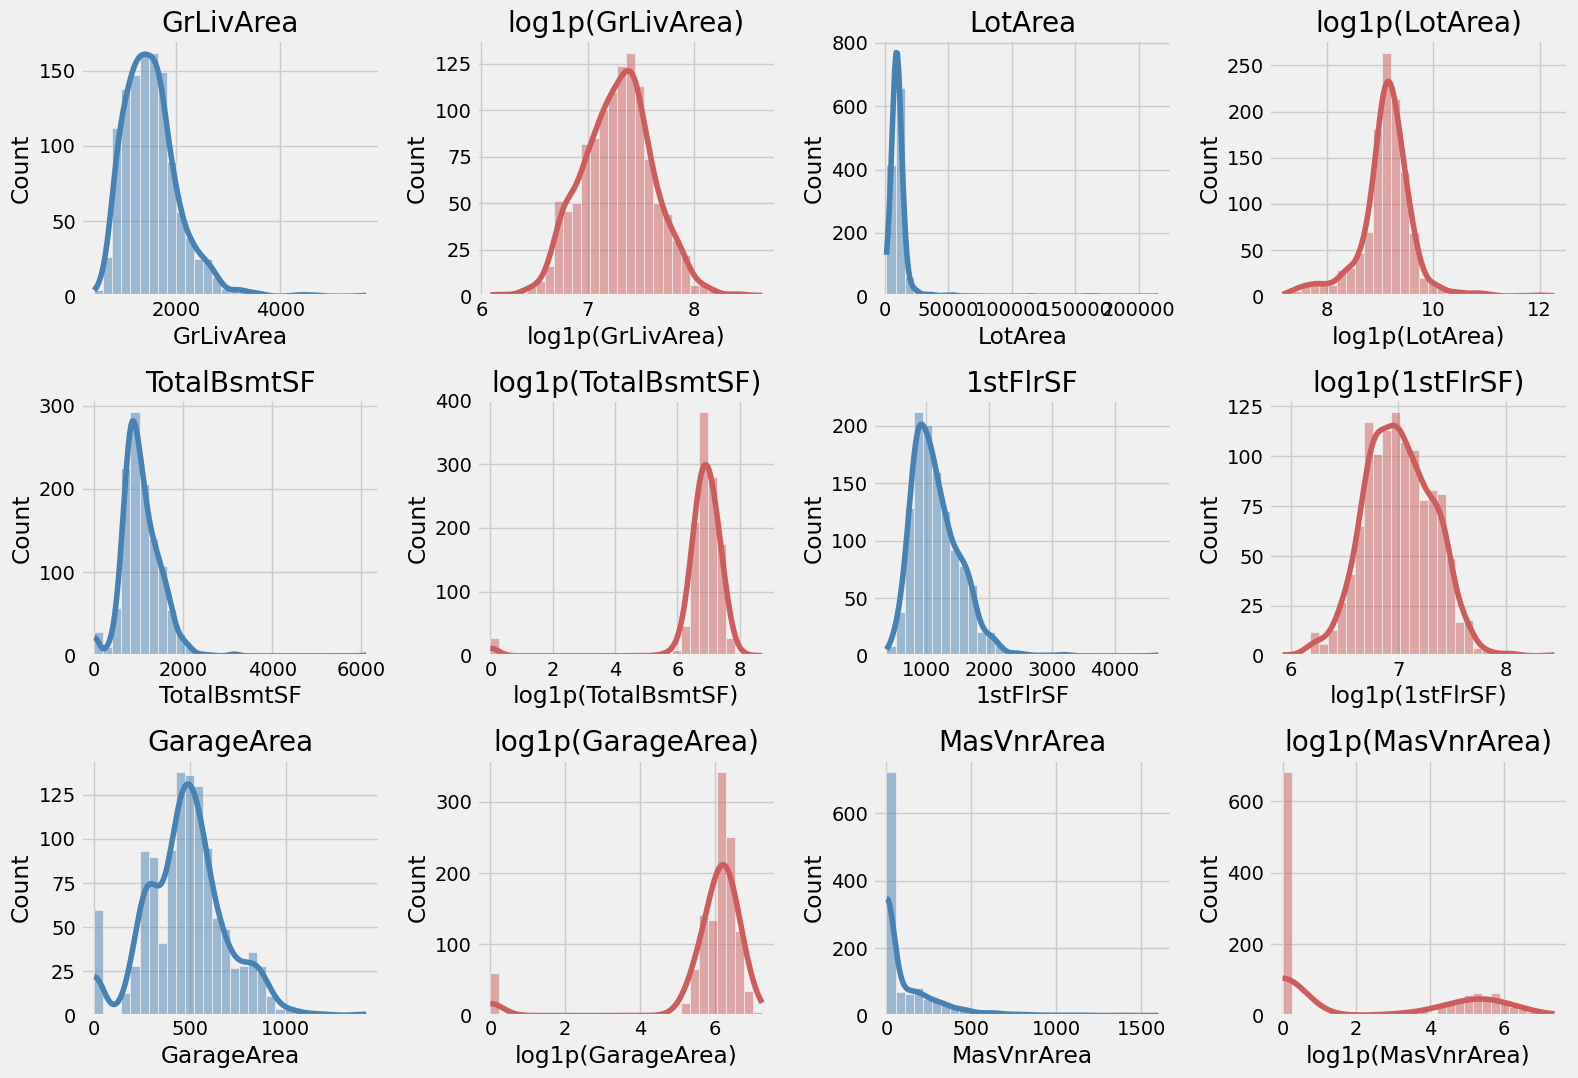

In [40]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for index, feature in enumerate(distribution_features):
    raw_axis, log_axis = axes[index * 2:index * 2 + 2]

    sns.histplot(distribution_df[feature], bins=30, kde=True, ax=raw_axis, color='steelblue')
    raw_axis.set_title(feature)
    raw_axis.set_xlabel(feature)

    sns.histplot(log_transformed_features[feature], bins=30, kde=True, ax=log_axis, color='indianred')
    log_axis.set_title(f'log1p({feature})')
    log_axis.set_xlabel(f'log1p({feature})')

plt.tight_layout()
plt.show()

In [41]:
numerical_profile = pd.DataFrame({
    'unique_values': features_df[numerical_columns].nunique(),
    'minimum': features_df[numerical_columns].min(),
    'missing_count': features_df[numerical_columns].isna().sum(),
    'zero_share': features_df[numerical_columns].eq(0).mean() * 100,
    'skewness': features_df[numerical_columns].skew(),
})

numerical_profile['abs_skewness'] = numerical_profile['skewness'].abs()
numerical_profile = numerical_profile.sort_values('abs_skewness', ascending=False)

display(numerical_profile.round(3))

,unique_values,minimum,missing_count,zero_share,skewness,abs_skewness
feature,,,,,,
MiscVal,18,0.0,0,96.575,22.571,22.571
PoolArea,7,0.0,0,99.486,14.371,14.371
LotArea,899,1300.0,0,0.000,11.408,11.408
3SsnPorch,18,0.0,0,98.202,9.625,9.625
LowQualFinSF,20,0.0,0,98.116,8.861,8.861
KitchenAbvGr,4,0.0,0,0.086,4.513,4.513
BsmtFinSF2,117,0.0,0,89.041,4.337,4.337
ScreenPorch,65,0.0,0,92.209,4.159,4.159
BsmtHalfBath,3,0.0,0,94.264,4.099,4.099


### Вывод

Профиль numerical features показал, что высокий skewness часто вызван не обычной асимметрией, а большим количеством структурных нулей. Поэтому применять `log1p` автоматически ко всем features с `|skewness| > 0.75` нельзя.

Кандидат на `log1p` должен:

- быть continuous numerical feature;
- принимать неотрицательные значения;
- иметь выраженную асимметрию;
- не быть годом, rating или discrete count;
- не состоять преимущественно из структурных нулей.

Основными кандидатами на `log1p` являются `LotArea`, `LotFrontage`, `1stFlrSF` и `GrLivArea`. Для `LotFrontage` преобразование будет выполняться после заполнения настоящих пропусков.

`GarageArea` имеет почти симметричное распределение и не требует логарифмирования. `YearBuilt`, `YearRemodAdd` и `GarageYrBlt` будем использовать для создания возрастов дома, ремонта и гаража.

Для zero-inflated features одного `log1p` недостаточно. Для них проверим indicators:

- `HasPool`;
- `HasGarage`;
- `HasBasement`;
- `HasMasVnr`;
- `HasSecondFloor`;
- indicators для веранд и дополнительных построек.

Первый linear baseline построим без distribution transformations: numerical features заполним и масштабируем, а categorical features закодируем через One-Hot Encoding. Затем отдельными CV-экспериментами проверим `log1p`, indicators и `QuantileTransformer`. Окончательное решение примем по `RMSE(log)` на одинаковых folds.

## 9. Распределения categorical features

Рассмотрим распределение `log(SalePrice)` для наиболее значимых categorical features. Для structural missing используем отдельные содержательные категории `NoBasement` и `NoGarage`.

In [42]:
categorical_plot_df = eda_df.copy()
categorical_plot_df['log_SalePrice'] = target_log

# Structural missing обозначает отсутствие соответствующего объекта
categorical_plot_df['BsmtQual'] = categorical_plot_df['BsmtQual'].astype('object').fillna('NoBasement')
categorical_plot_df['GarageFinish'] = categorical_plot_df['GarageFinish'].astype('object').fillna('NoGarage')

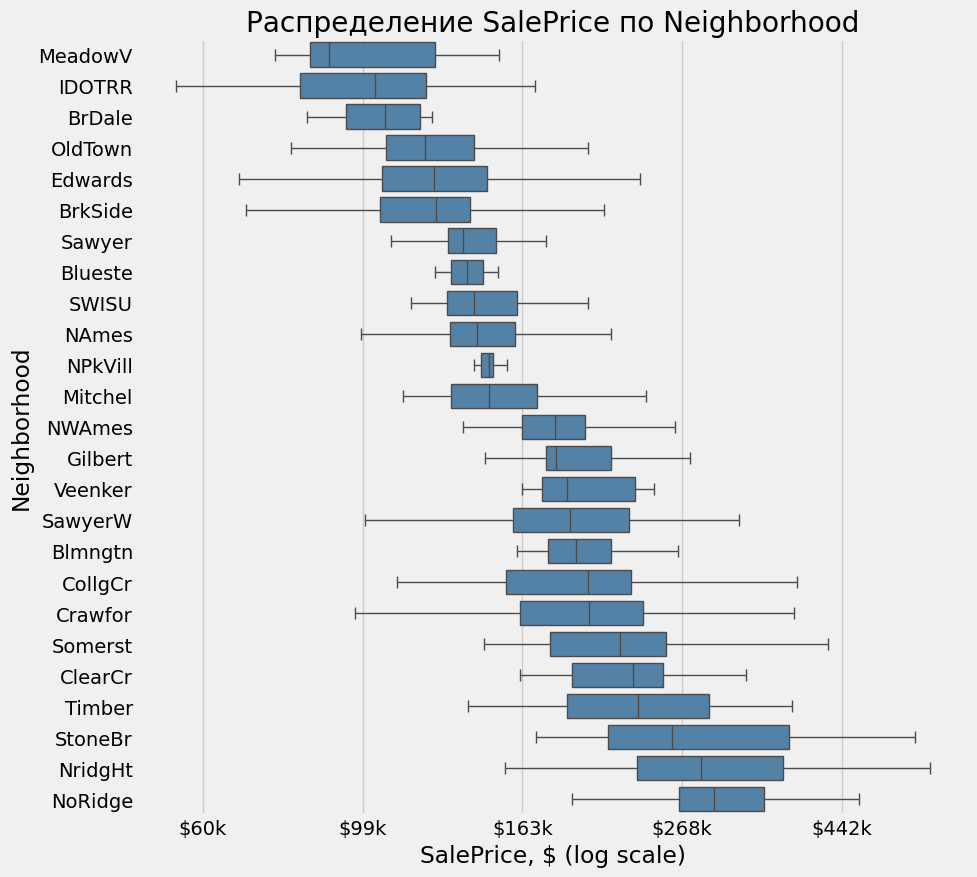

In [43]:
# Сортируем районы по медианной стоимости
neighborhood_order = categorical_plot_df.groupby('Neighborhood')['log_SalePrice'].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 9))

sns.boxplot(data=categorical_plot_df, x='log_SalePrice', y='Neighborhood', order=neighborhood_order, color='steelblue', showfliers=False, ax=ax)

ax.set_title('Распределение SalePrice по Neighborhood')
ax.set_xlabel('SalePrice, $ (log scale)')
ax.set_ylabel('Neighborhood')
ax.xaxis.set_major_formatter(log_price_formatter)

plt.tight_layout()
plt.show()

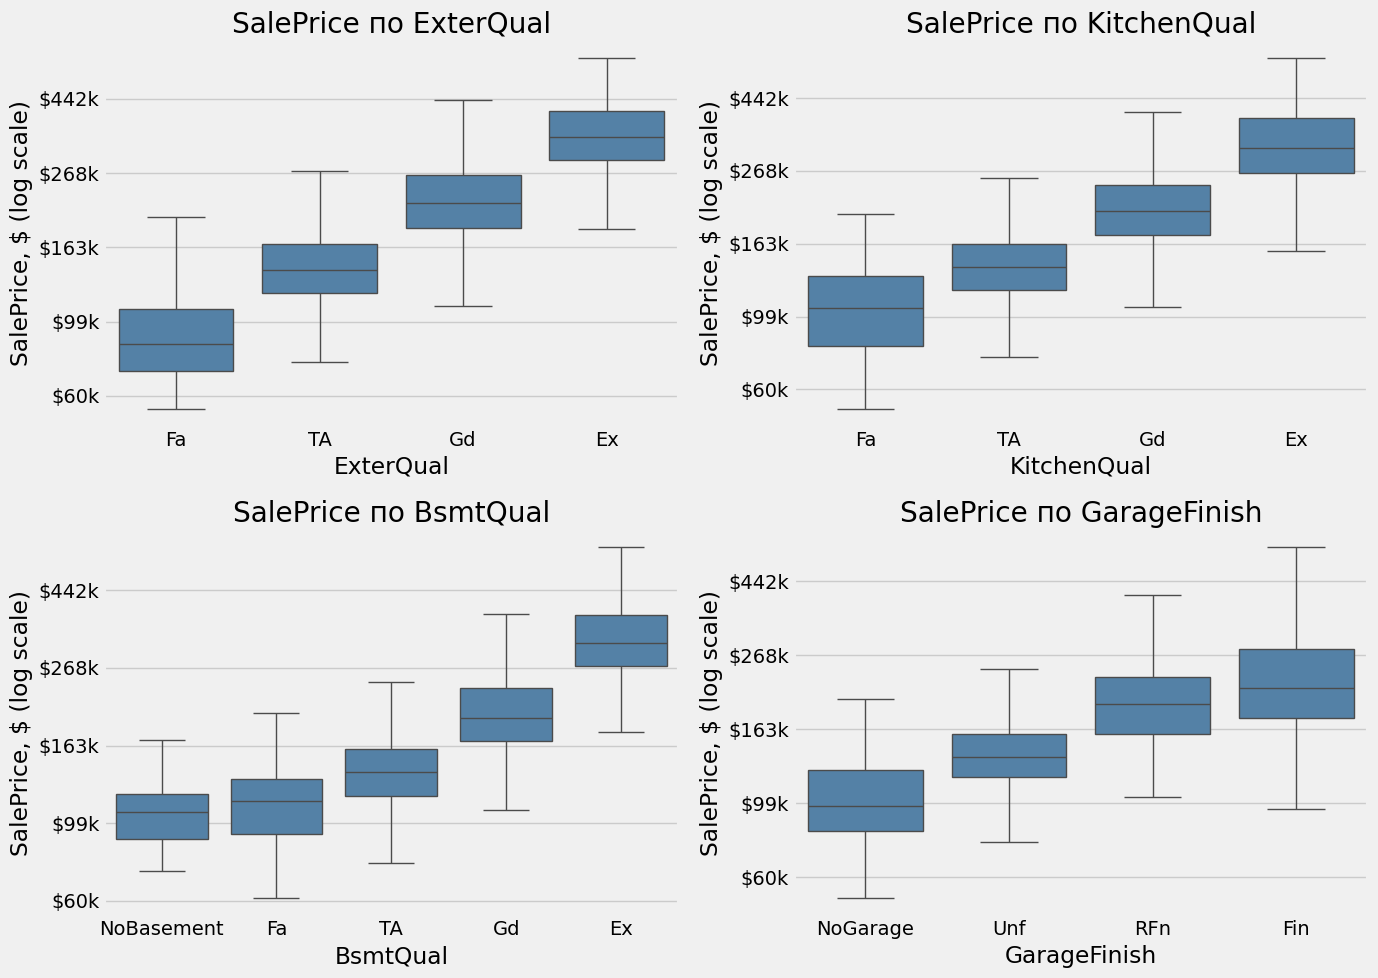

In [44]:
quality_features = ['ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish']

category_orders = {
    'ExterQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual': ['NoBasement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageFinish': ['NoGarage', 'Unf', 'RFn', 'Fin'],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for feature, axis in zip(quality_features, axes.flat):
    available_order = [category for category in category_orders[feature] if category in categorical_plot_df[feature].unique()]

    sns.boxplot(data=categorical_plot_df, x=feature, y='log_SalePrice', order=available_order, color='steelblue', showfliers=False, ax=axis)

    axis.set(title=f'SalePrice по {feature}', xlabel=feature, ylabel='SalePrice, $ (log scale)')
    axis.yaxis.set_major_formatter(log_price_formatter)

plt.tight_layout()
plt.show()

### Вывод

`Neighborhood` заметно разделяет дома по стоимости, что подтверждает его первое место по `eta_squared`. Наиболее дорогие дома чаще расположены в `NoRidge`, `NridgHt` и `StoneBr`, а наиболее дешёвые — в `MeadowV`, `IDOTRR` и `BrDale`. При этом распределения соседних районов перекрываются: расположение важно, но не определяет цену без учёта площади и качества дома.

`ExterQual`, `KitchenQual` и `BsmtQual` показывают выраженный последовательный рост цены от низкого качества к высокому. У `GarageFinish` также наблюдается рост от отсутствующего или незавершённого гаража к полностью отделанному, хотя отдельные категории сильнее перекрываются.

Structural missing в `BsmtQual` и `GarageFinish` содержат полезную информацию: категории `NoBasement` и `NoGarage` связаны с более низкой стоимостью и должны сохраняться как отдельные значения.

Для первого linear baseline categorical features закодируем через One-Hot Encoding. Поскольку quality categories имеют естественный порядок, позднее отдельно проверим ordinal encoding, но его пользу будем оценивать только по CV.